In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.options.display.float_format = '{:.2f}'.format

In [ ]:
# Load and filter
qSales = pd.read_csv('qSales_2024.csv')
qSales['datadate'] = pd.to_datetime(qSales['datadate'])
target_sales = qSales[qSales['tic'] == 'TGT']
display(target_sales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A


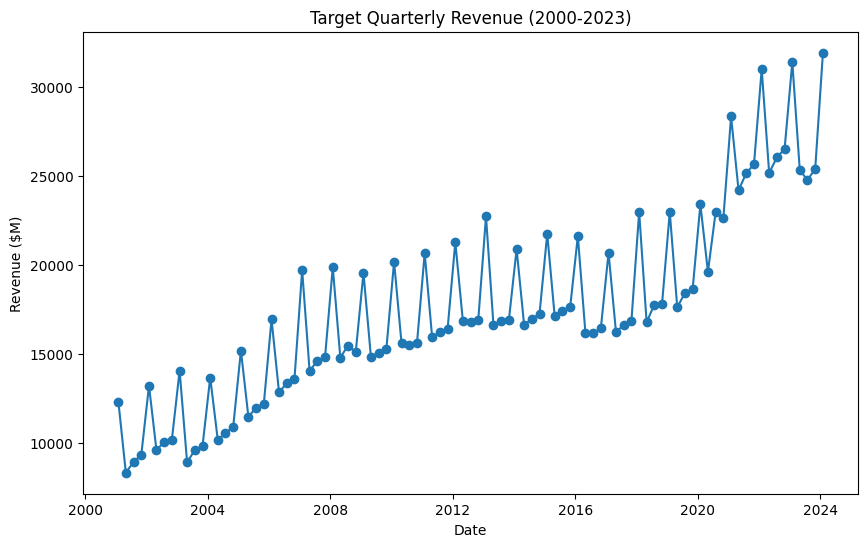

In [ ]:
# Step 1: Visualize data
plt.figure(figsize=(10,6))

plt.title('Target Quarterly Revenue (2000-2023)')
plt.xlabel('Date')
plt.ylabel('Revenue ($M)')

plt.plot(target_sales['datadate'], target_sales['saleq'], marker='o')
plt.show()

From the graph above, we can see that Target's revenue cyclically spikes up in Q4, which can be attributed to increased holiday sales during that time period (November 1 to January 31).

Furthermore, starting from 2020 Q2, Target experienced a surge in revenue, driven by digital adoption during and after COVID-19; namely, the pandemic accelerated e-commerce channels such as online shopping and curb pickup, which brought more customers as a result.

In [ ]:
# Step 2: Add time variable and 2 dummy variables
# Time variable
target_sales['time'] = range(1, len(target_sales) + 1)

# Dummy variable 1: Holiday shopping season
target_sales['holiday_dv'] = np.where(target_sales['fqtr']==4, 1, 0)
target_sales['holiday_interaction'] = target_sales['time'] * target_sales['holiday_dv']

# Dummy variable 2: Post-COVID revenues
target_sales['postCovid_dv'] = np.where(target_sales['datacqtr'] >= '2020Q2', 1, 0)
target_sales['postCovid_interaction'] = target_sales['time'] * target_sales['postCovid_dv']

/tmp/ipykernel_46957/1303419509.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_sales['time'] = range(1, len(target_sales) + 1)
/tmp/ipykernel_46957/1303419509.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_sales['holiday_dv'] = np.where(target_sales['fqtr']==4, 1, 0)
/tmp/ipykernel_46957/1303419509.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentat

In [ ]:
(target_sales).tail(15)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,...,curcdq,datacqtr,datafqtr,saleq,costat,time,holiday_dv,holiday_interaction,postCovid_dv,postCovid_interaction
170,3813,2020-07-31,2020,2,1,INDL,C,D,STD,TGT,...,USD,2020Q2,2020Q2,22975.00,A,79,0,0,1,79
171,3813,2020-10-31,2020,3,1,INDL,C,D,STD,TGT,...,USD,2020Q3,2020Q3,22632.00,A,80,0,0,1,80
172,3813,2021-01-31,2020,4,1,INDL,C,D,STD,TGT,...,USD,2020Q4,2020Q4,28339.00,A,81,1,81,1,81
173,3813,2021-04-30,2021,1,1,INDL,C,D,STD,TGT,...,USD,2021Q1,2021Q1,24197.00,A,82,0,0,1,82
174,3813,2021-07-31,2021,2,1,INDL,C,D,STD,TGT,...,USD,2021Q2,2021Q2,25160.00,A,83,0,0,1,83
175,3813,2021-10-31,2021,3,1,INDL,C,D,STD,TGT,...,USD,2021Q3,2021Q3,25652.00,A,84,0,0,1,84
176,3813,2022-01-31,2021,4,1,INDL,C,D,STD,TGT,...,USD,2021Q4,2021Q4,30996.00,A,85,1,85,1,85
177,3813,2022-04-30,2022,1,1,INDL,C,D,STD,TGT,...,USD,2022Q1,2022Q1,25170.00,A,86,0,0,1,86
178,3813,2022-07-31,2022,2,1,INDL,C,D,STD,TGT,...,USD,2022Q2,2022Q2,26037.00,A,87,0,0,1,87
179,3813,2022-10-31,2022,3,1,INDL,C,D,STD,TGT,...,USD,2022Q3,2022Q3,26518.00,A,88,0,0,1,88


Since only about 16.13%  of the dataset (15/93 rows) is 2020 Q2 afterwards, the 75% training data and 25% testing data split won't work for the post-COVID dummy variable. As such, I have decided to use the full dataset instead.

In [ ]:
# Step 3: Fit model on full dataset
y = target_sales.loc[:, 'saleq']
x = target_sales.loc[:, ['time', 'holiday_dv', 'holiday_interaction', 'postCovid_dv', 'postCovid_interaction']]
x = sm.add_constant(x)

model1 = sm.OLS(y,x).fit()

model1.params

,0
const,9744.83
time,123.92
holiday_dv,3955.93
holiday_interaction,16.95
postCovid_dv,-2659.14
postCovid_interaction,84.20


In [ ]:
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  saleq   R-squared:                       0.956
Model:                            OLS   Adj. R-squared:                  0.953
Method:                 Least Squares   F-statistic:                     373.7
Date:                Mon, 27 Jul 2026   Prob (F-statistic):           3.32e-57
Time:                        05:47:29   Log-Likelihood:                -784.53
No. Observations:                  93   AIC:                             1581.
Df Residuals:                      87   BIC:                             1596.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                  9744.8340    301.792     32.290      0.000    9144.990    1.03e+04
time                    123.9229      6.404     19.352      0.000     111.195     136.651
holiday_dv             3955.9293    543.419      7.280      0.000    2875.826    5036.033
holiday_interaction      16.9499     10.016      1.692      0.094      -2.959      36.859
postCovid_dv          -2659.1449   5970.581     -0.445      0.657   -1.45e+04    9208.032
postCovid_interaction    84.1976     69.519      1.211      0.229     -53.978     222.373
==============================================================================
Omnibus:                       19.178   Durbin-Watson:                   0.255
Prob(Omnibus):                  0.000   Jarque-Bera (JB):                4.680
Skew:                           0.030   Prob(JB):                       0.0963
Kurtosis:                       1.903   Cond. No.                     3.07e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.07e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

$TargetRevenue = 9,744.83 + 123.92 × time + 3,955.93 × holiday + 16.95 × (time × holiday) - 2,659.14 × postCovid + 84.20 × (time × postCovid)$

In [ ]:
# Step 4: Fit values and get summary frame with a confidence level
pred_summary = model1.get_prediction(x).summary_frame(alpha=0.2) # 80% confidence level
target_sales['predicted'] = pred_summary['mean']
target_sales['pred_lower'] = pred_summary['obs_ci_lower']
target_sales['pred_upper'] = pred_summary['obs_ci_upper']

display(pred_summary)

/tmp/ipykernel_46957/1199810385.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_sales['predicted'] = pred_summary['mean']
/tmp/ipykernel_46957/1199810385.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_sales['pred_lower'] = pred_summary['obs_ci_lower']
/tmp/ipykernel_46957/1199810385.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pand

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
92,13841.64,468.25,13236.96,14446.31,12234.49,15448.79
93,9992.68,290.73,9617.24,10368.12,8457.02,11528.34
94,10116.60,285.26,9748.24,10484.97,8582.65,11650.55
95,10240.53,279.82,9879.18,10601.87,8708.25,11772.80
96,14405.13,436.86,13840.98,14969.28,12812.78,15997.47
...,...,...,...,...,...,...
180,31072.88,500.63,30426.39,31719.37,29449.53,32696.23
181,25816.53,438.79,25249.90,26383.16,24223.30,27409.76
182,26024.65,488.35,25394.01,26655.29,24407.55,27641.75
183,26232.77,542.33,25532.43,26933.12,24587.24,27878.31


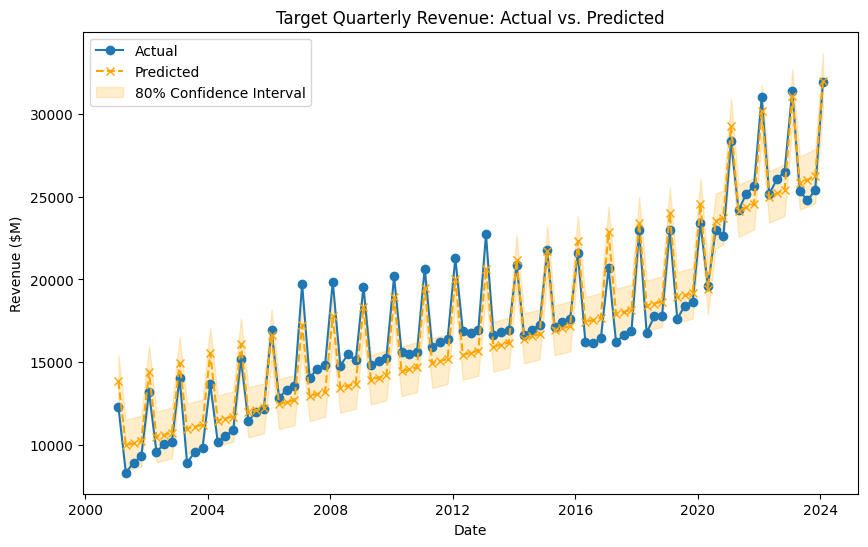

In [ ]:
# Step 4: Show actual vs. predicted visualization, with confidence intervals
plt.figure(figsize=(10,6))

plt.title('Target Quarterly Revenue: Actual vs. Predicted')
plt.xlabel('Date')
plt.ylabel('Revenue ($M)')

plt.plot(target_sales['datadate'], target_sales['saleq'], marker='o', label='Actual')
plt.plot(target_sales['datadate'], target_sales['predicted'], marker='x', linestyle='--', color='orange', label='Predicted')
plt.fill_between(target_sales['datadate'], target_sales['pred_lower'], target_sales['pred_upper'],
                 color='orange', alpha=0.2, label='80% Confidence Interval')

plt.legend()
plt.show()

# MEMORANDUM
**To:** Chapman Wealth Management

**CC:** Hypatia, Manager - QuantFolio Solutions

**From:** Christine Miao, Intern - QuantFolio Solutions

**Date:** July 24, 2026

**Re:** Target Corporation - Quarterly Revenue Regression Analysis

---
From our analysis, we found that Target's quarterly revenues follow a seasonal pattern and demonstrates a growing underlying trend overall. Understanding Target's revenue patterns assists with Chapman Wealth Management's goal of evaluating their investment in Target Corporation.


## Scope
Our objective is to create a regression model that reflects Target's revenue patterns and plot the predicted results against actual revenue data. The provided quarterly revenue data spans 23 years from January 31, 2001 to January 31, 2024. Our confidence level for the predicted results is 80%.

## Methodology
By loading the qSales_2024.csv file and plotting a graph for examination, we have identified two notable trends: 1. Target's revenue is cyclical, spiking up in Q4, and 2. Target experienced a surge in revenue starting from 2020 Q2. We used the respective timeframes to create dummy variables holiday_dv and postCovid_dv. We multiplied the x-variable (time) by the dummy variables to get the corresponding interaction terms, holiday_interaction and postCovid_interaction. Our derived equation is $TargetRevenue = 9,744.83 + 123.92 × time + 3,955.93 × holiday + 16.95 × (time × holiday) - 2,659.14 × postCovid + 84.20 × (time × postCovid)$

## Key Findings
**Holiday Dummy Variable (holiday_dv):** Target's revenue is cyclical and consistently spikes up in fiscal Q4, which can be attributed to increased holiday sales during that time period (November 1 to January 31). Depending on if it's Q4, the revenue jump is $3,955.93 million above other quarters, and the slope shift from the interaction term (time × holiday) is 16.95, suggesting this seasonal lift has increased only modestly over time in dollar terms.

**Post-COVID Dummy Variable (postCovid_DV):** This dummy variable captures the surge in consumer spending at Target beginning 2020 Q2, driven by factors like accelerated digital adoption of online shopping and curbside pickup during and post-pandemic. Rather than reverting after the initial pandemic shock, revenue has remained elevated at this new level through the most recent data (2023 Q4). Overall upward trend shows growth throughout the years.

**Regression Model Fit:** The adjusted R-squared of 0.953 indicates that the model explains approximately 95.3% of the quarter-to-quarter variation in Target's revenue, which is a strong fit. With an 80% confidence level, the interval range (obs_ci_upper - obs_ci_lower) hovers consistently around $3,200, and the actual observation frequently falls within that interval from the predicted results.

## Recommendations
**1. Conduct Qualitative Analysis:** Look beyond the figures by gaining knowledge about Target's internal affairs and grasping the rationale behind management's business decisions. Investor relations such as conference calls and quarterly report presentations can be informative.

**2. Analyze Other Business Metrics:** Revenue is only one indicator of operational health; evaluating Target's performance by examining key financial ratios across profitability, liquidity, efficiency, and solvency, and comparing them against industry benchmarks may be more insightful in putting Target's competitive position into perspective.

**3. Forecast Future Revenue with Currently Available Information:** While the spikes can be expected to continue due to their seasonal nature, the revenue shift brought by the pandemic is a relatively recent development: it wouldn't be prudent to assume that the lift will persist indefinitely. Stay up-to-date with the latest news and account for relevant information in future revenue forcasts.